# Trek Personas: K-Means Clustering & KNN Prediction

This notebook applies K-Means clustering to discover "Trek Personas" based on the preprocessed features, and then trains a K-Nearest Neighbors (KNN) classifier to predict these personas.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Load Data
We load both the scaled and unscaled preprocessed datasets.

In [13]:
df_scaled = pd.read_csv('datasets/processed/trek_preprocessed_scaled.csv')
df_unscaled = pd.read_csv('datasets/processed/trek_preprocessed_unscaled.csv')

print(f"Scaled data shape: {df_scaled.shape}")
df_scaled.head(3)

Scaled data shape: (383, 15)


,Trek,Cost_USD,Duration_Days,Max_Altitude_m,Trip_Grade_Ordinal,Accom_Guesthouse,Accom_Lodge,Accom_LuxuryLodge,Accom_Teahouse,Accom_TeahouseLodge,Travel_AprMay_SeptNov,Travel_JanMay_SeptDec,Travel_MarMay_SeptDec,Travel_MarMay_SeptNov,Travel_MarNov
0,Everest Base Camp Trek,1420.0,0.316548,0.886078,-0.377885,1,0,0,0,0,0,0,1,0,0
1,Everest Base Camp Short Trek,1295.0,-0.124317,0.886078,-0.377885,1,0,0,0,0,0,0,1,0,0
2,Everest Base Camp Heli Shuttle Trek,2000.0,-0.565183,0.886078,-0.377885,1,0,0,0,0,0,0,1,0,0


## 2. Prepare Features for Clustering
Scale `Cost_USD` and define the feature matrix `X`.

In [14]:
scaler = StandardScaler()
df_scaled['Cost_USD_scaled'] = scaler.fit_transform(df_scaled[['Cost_USD']])

# Select features for clustering
X = df_scaled.drop(columns=['Trek', 'Cost_USD'])
feature_cols = X.columns.tolist()

print(f"Features used for clustering: {feature_cols}")

Features used for clustering: ['Duration_Days', 'Max_Altitude_m', 'Trip_Grade_Ordinal', 'Accom_Guesthouse', 'Accom_Lodge', 'Accom_LuxuryLodge', 'Accom_Teahouse', 'Accom_TeahouseLodge', 'Travel_AprMay_SeptNov', 'Travel_JanMay_SeptDec', 'Travel_MarMay_SeptDec', 'Travel_MarMay_SeptNov', 'Travel_MarNov', 'Cost_USD_scaled']


## 3. Finding Optimal k (Elbow & Silhouette)

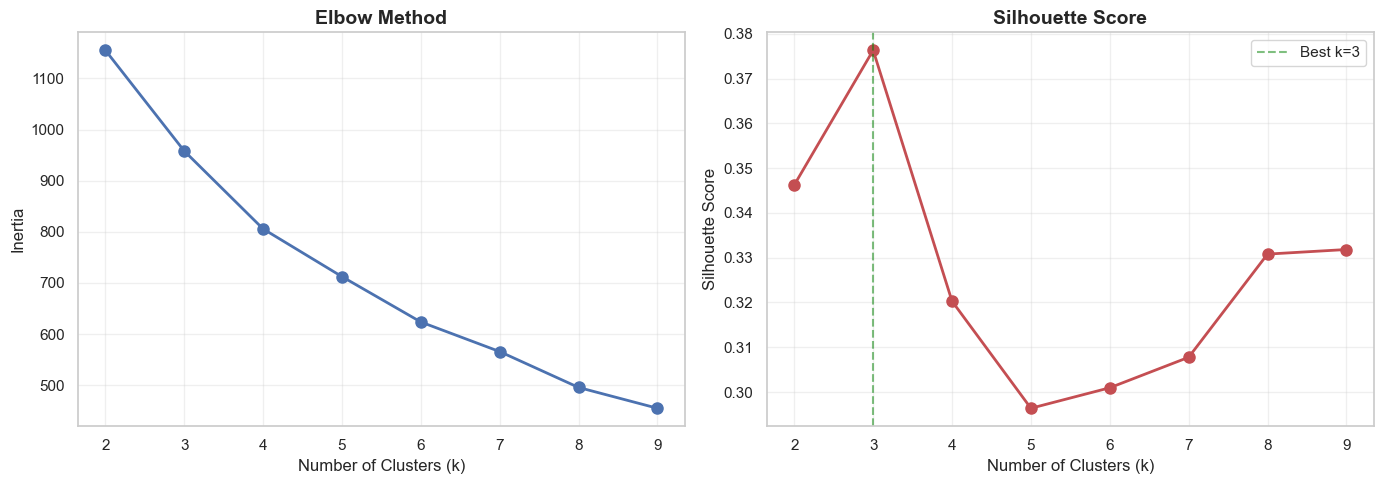


✅ Best k by silhouette score: 3


In [15]:
K_range = range(2, 10)
inertias = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

# Highlight best k
best_k = K_range[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='green', linestyle='--', alpha=0.5, label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n✅ Best k by silhouette score: {best_k}")

## 4. Fit K-Means & Assign Personas
We use K=5 to identify 5 distinct trekking personas.

In [16]:
OPTIMAL_K = 5
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X)

df_scaled['Cluster'] = clusters
df_unscaled['Cluster'] = clusters

centroids = pd.DataFrame(kmeans_final.cluster_centers_, columns=feature_cols)
centroids.index.name = 'Cluster'
print("Cluster Centroids (Scaled Features):")
display(centroids.round(3))

Cluster Centroids (Scaled Features):


,Duration_Days,Max_Altitude_m,Trip_Grade_Ordinal,Accom_Guesthouse,Accom_Lodge,Accom_LuxuryLodge,Accom_Teahouse,Accom_TeahouseLodge,Travel_AprMay_SeptNov,Travel_JanMay_SeptDec,Travel_MarMay_SeptDec,Travel_MarMay_SeptNov,Travel_MarNov,Cost_USD_scaled
Cluster,,,,,,,,,,,,,,
0,-0.186,-0.161,-0.182,0.896,0.000,0.000,0.104,0.000,-0.000,0.885,0.010,0.104,0.000,0.056
1,0.793,0.753,0.981,1.000,0.000,0.000,-0.000,0.000,0.006,0.844,0.013,0.136,0.000,0.157
2,-1.242,-1.703,-1.279,0.649,0.088,0.088,0.088,0.088,0.000,0.912,0.088,-0.000,-0.000,-0.883
3,0.116,-0.007,-0.805,0.500,0.227,-0.000,0.273,-0.000,0.000,0.227,0.091,0.455,0.227,2.671
4,-0.667,-0.061,-0.796,0.630,0.000,0.000,0.370,0.000,0.000,0.000,1.000,-0.000,0.000,-0.704


In [17]:
# Assign persona names based on cluster characteristics (e.g. Max Altitude and Cost)
persona_summary = df_unscaled.groupby('Cluster').agg({
    'Max_Altitude_m': 'mean',
    'Duration_Days': 'mean',
    'Cost_USD': 'mean'
})

# Sort by Max Altitude to create a logical progression
sorted_clusters = persona_summary.sort_values(by='Max_Altitude_m', ascending=False).index.tolist()

persona_names = [
    '🏔️ Extreme Altitude Expeditions',
    '🌄 High Altitude Classics',
    '🗺️ Moderate Adventure Treks',
    '🎒 Cultural Teahouse Treks',
    '🚶 Short Budget Escapes'
]

persona_map = {sorted_clusters[i]: persona_names[i] for i in range(OPTIMAL_K)}

df_unscaled['Persona'] = df_unscaled['Cluster'].map(persona_map)
df_scaled['Persona'] = df_scaled['Cluster'].map(persona_map)

print("\n🎯 Trek Personas Assigned:")
print(df_unscaled['Persona'].value_counts())



🎯 Trek Personas Assigned:
Persona
🏔️ Extreme Altitude Expeditions    154
🎒 Cultural Teahouse Treks           96
🚶 Short Budget Escapes              57
🗺️ Moderate Adventure Treks         54
🌄 High Altitude Classics            22
Name: count, dtype: int64


## 5. Visualizations

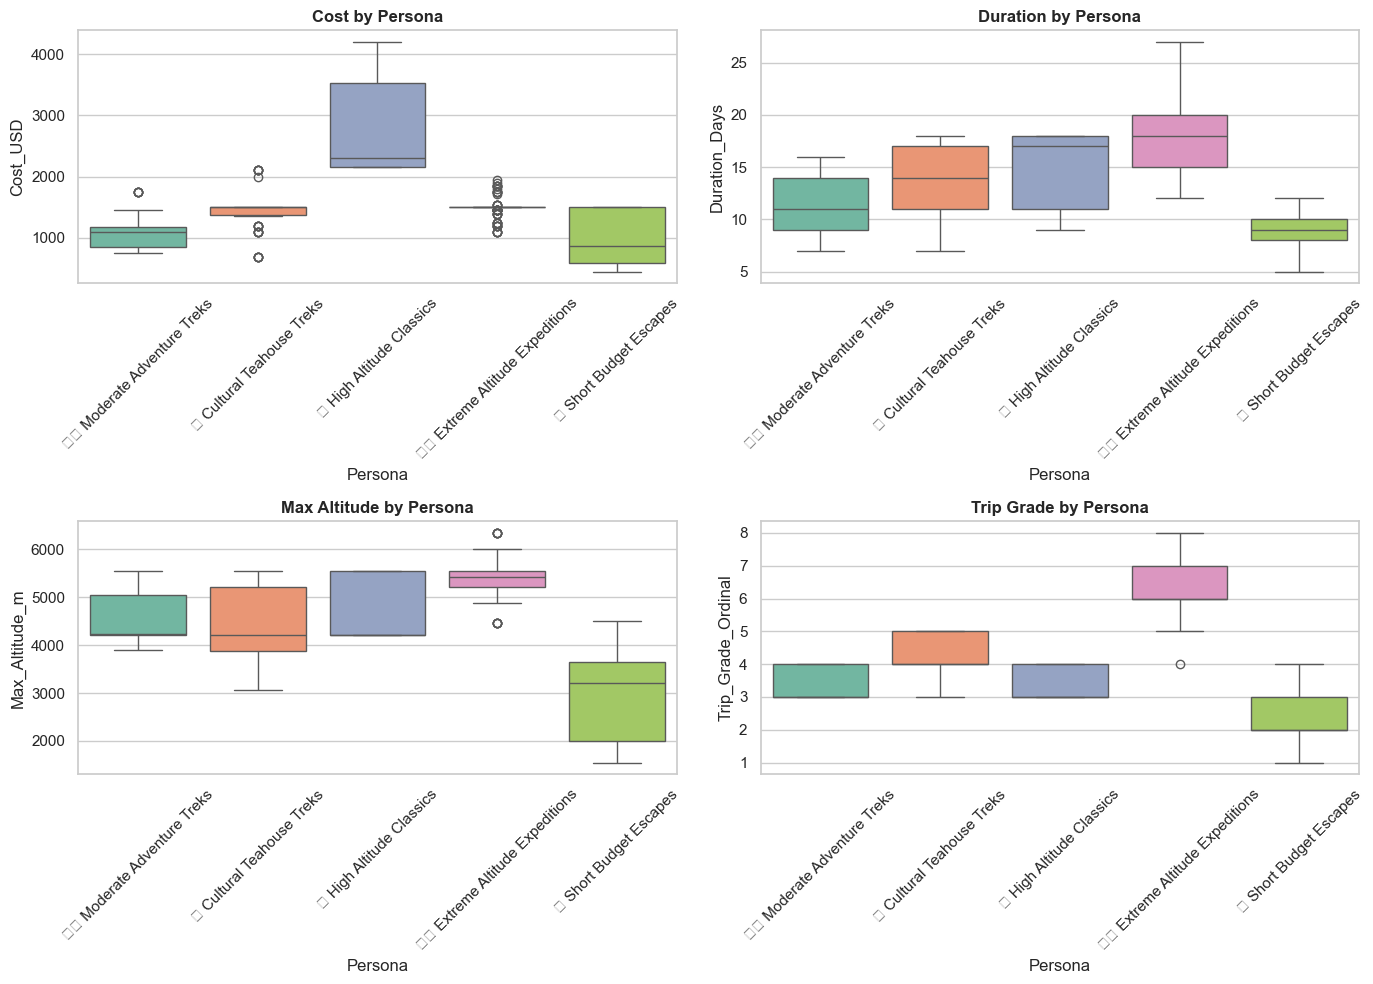

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df_unscaled, x='Persona', y='Cost_USD', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Cost by Persona', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_unscaled, x='Persona', y='Duration_Days', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Duration by Persona', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_unscaled, x='Persona', y='Max_Altitude_m', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Max Altitude by Persona', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_unscaled, x='Persona', y='Trip_Grade_Ordinal', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Trip Grade by Persona', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

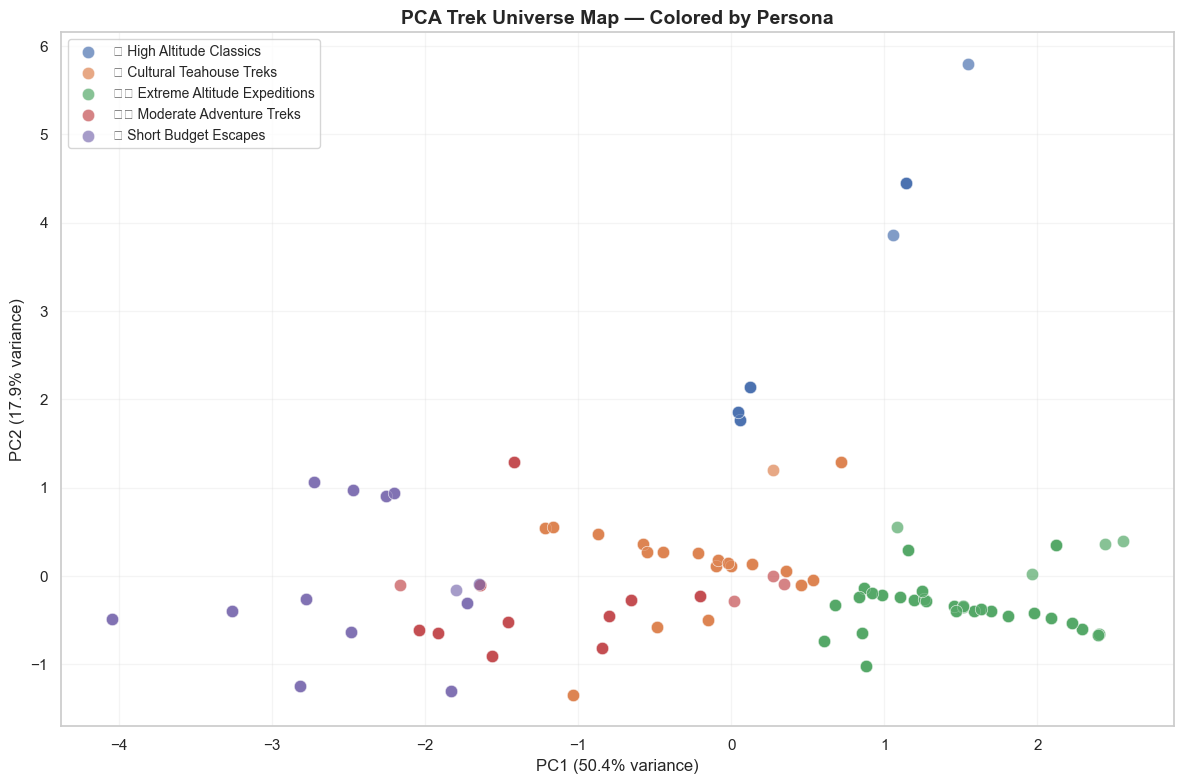

In [19]:
# PCA 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))

for persona in sorted(df_unscaled['Persona'].unique()):
    mask = df_unscaled['Persona'] == persona
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
              label=persona, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA Trek Universe Map — Colored by Persona', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 6. KNN Classifier — Persona Prediction
We train a K-Nearest Neighbors classifier to predict a trek's persona based on its features.

✅ Best k for KNN: 1
Best CV Accuracy: 0.9902


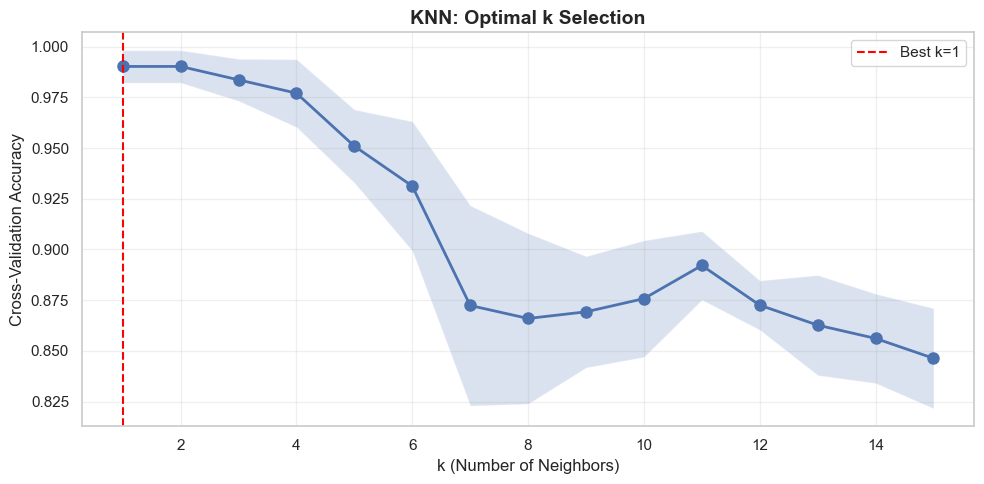

In [20]:
X_knn = X.values
y_knn = df_unscaled['Cluster'].values

X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42, stratify=y_knn)

scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

# Grid search for optimal k
param_grid = {'n_neighbors': range(1, min(16, len(X_train) - 1))}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=min(5, len(y_train)//5), scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_k_knn = grid_search.best_params_['n_neighbors']
print(f"✅ Best k for KNN: {best_k_knn}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

results = grid_search.cv_results_
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(param_grid['n_neighbors'], results['mean_test_score'], 'bo-', linewidth=2, markersize=8)
ax.fill_between(param_grid['n_neighbors'], 
                results['mean_test_score'] - results['std_test_score'],
                results['mean_test_score'] + results['std_test_score'],
                alpha=0.2)
ax.axvline(x=best_k_knn, color='red', linestyle='--', label=f'Best k={best_k_knn}')
ax.set_xlabel('k (Number of Neighbors)')
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('KNN: Optimal k Selection', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KNN Classification Report:
                                 precision    recall  f1-score   support

      🎒 Cultural Teahouse Treks       1.00      1.00      1.00        19
🏔️ Extreme Altitude Expeditions       1.00      0.97      0.98        31
         🚶 Short Budget Escapes       1.00      1.00      1.00        12
       🌄 High Altitude Classics       1.00      1.00      1.00         4
    🗺️ Moderate Adventure Treks       0.92      1.00      0.96        11

                       accuracy                           0.99        77
                      macro avg       0.98      0.99      0.99        77
                   weighted avg       0.99      0.99      0.99        77



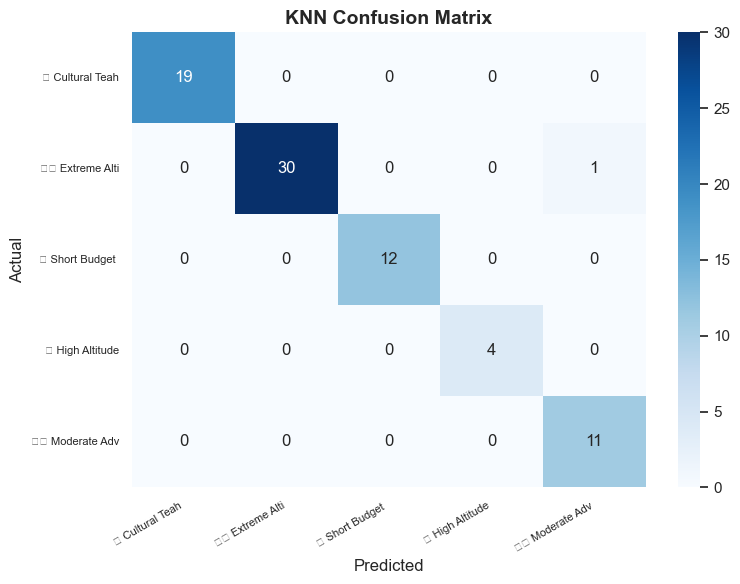


✅ KNN Test Accuracy: 0.9870


In [21]:
# KNN final evaluation
knn_final = KNeighborsClassifier(n_neighbors=best_k_knn)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)

print("KNN Classification Report:")
# Generate target names that map 0..OPTIMAL_K-1 to their respective persona names
target_names = []
for i in range(OPTIMAL_K):
    if i in persona_map:
        target_names.append(persona_map[i])
    else:
        target_names.append(f"Cluster {i}")

print(classification_report(y_test, y_pred_knn, target_names=target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[n[:15] for n in target_names],
            yticklabels=[n[:15] for n in target_names])
ax.set_title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"\n✅ KNN Test Accuracy: {knn_accuracy:.4f}")